# Persistent Tip State GPU Optimization — Branch Length Estimation

Comparing the **persistent tip state** GPU build against:
- **GPU Baseline** (V100, standard OpenACC)
- **GPU maxregcount** (V100, register-count optimization)
- **CPU backends**: VANILA (1-core), OMP_10, OMP_48

Models: AA/LG and DNA/GTR (unrooted)  
100 taxa, 1M sites, 10 trees, 10 runs each

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

TIP_STATE_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_persistent_tip_state')
OPT_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation_opt')
BASELINE_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation')
SAVE_DIR = Path('.')

## 1. Parse All Log Files

In [2]:
def parse_log(filepath):
    try:
        with open(filepath, 'r') as f:
            text = f.read()
    except Exception:
        return None
    
    result = {}
    
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)\s+sec', text)
    if m:
        result['walltime'] = float(m.group(1))
    
    m = re.search(r'Total CPU time used:\s+([\d.]+)\s+sec', text)
    if m:
        result['cputime'] = float(m.group(1))
    
    m = re.search(r'BEST SCORE FOUND\s*:\s*([\-\d.]+)', text)
    if m:
        result['log_likelihood'] = float(m.group(1))
    
    m = re.search(r'Total tree length:\s+([\d.]+)', text)
    if m:
        result['tree_length'] = float(m.group(1))
    
    m = re.search(r'Parameters optimization took \d+ rounds \(([\d.]+) sec\)', text)
    if m:
        result['opt_time'] = float(m.group(1))
    
    return result if 'walltime' in result else None


def extract_run_number(filename):
    matches = re.findall(r'_run(\d+)_', filename)
    return int(matches[-1]) if matches else None


def classify_backend(filename):
    if 'OPENACC' in filename:
        return 'OPENACC'
    elif 'VANILA' in filename:
        return 'VANILA'
    elif 'OMP_48' in filename:
        return 'OMP_48'
    elif 'OMP_10' in filename:
        return 'OMP_10'
    return 'UNKNOWN'


def parse_results_dir(base_dir, backend_override=None):
    rows = []
    for data_type in ['AA', 'DNA']:
        for tree_type in ['rooted', 'unrooted']:
            type_dir = base_dir / data_type / tree_type
            if not type_dir.exists():
                continue
            for model_dir in sorted(type_dir.iterdir()):
                if not model_dir.is_dir():
                    continue
                model = model_dir.name
                for tree_dir in sorted(model_dir.iterdir()):
                    if not tree_dir.is_dir():
                        continue
                    tree = tree_dir.name
                    for logfile in tree_dir.glob('*.log'):
                        fname = logfile.name
                        backend = backend_override if backend_override else classify_backend(fname)
                        run_num = extract_run_number(fname)
                        metrics = parse_log(logfile)
                        if metrics:
                            rows.append({
                                'data_type': data_type,
                                'tree_type': tree_type,
                                'model': model,
                                'tree': tree,
                                'backend': backend,
                                'run': run_num,
                                **metrics
                            })
    return rows

In [3]:
# Parse all three sources
rows_tip = parse_results_dir(TIP_STATE_DIR, backend_override='GPU_TIP_STATE')
rows_opt = parse_results_dir(OPT_DIR, backend_override='GPU_MAXREG')
rows_base = parse_results_dir(BASELINE_DIR)

df_tip = pd.DataFrame(rows_tip)
df_opt = pd.DataFrame(rows_opt)
df_base = pd.DataFrame(rows_base)

# Filter baseline to matching models (AA/LG, DNA/GTR, unrooted)
df_base = df_base[
    (df_base['tree_type'] == 'unrooted') &
    (
        ((df_base['data_type'] == 'AA') & (df_base['model'] == 'LG')) |
        ((df_base['data_type'] == 'DNA') & (df_base['model'] == 'GTR'))
    )
].copy()

df = pd.concat([df_base, df_opt, df_tip], ignore_index=True)
df.to_csv(SAVE_DIR / 'results_all.csv', index=False)

print(f'Persistent Tip State: {len(df_tip)} entries')
print(f'GPU maxregcount: {len(df_opt)} entries')
print(f'Baseline (filtered): {len(df_base)} entries')
print(f'\nCombined: {len(df)} entries')
print(df.groupby(['data_type', 'backend']).size().unstack(fill_value=0))

Persistent Tip State: 179 entries
GPU maxregcount: 120 entries
Baseline (filtered): 687 entries

Combined: 986 entries
backend    GPU_MAXREG  GPU_TIP_STATE  OMP_10  OMP_48  OPENACC  VANILA
data_type                                                            
AA                 70             99     100     100      137      20
DNA                50             80     100     100       90      40


## 2. Summary Statistics

In [4]:
summary = df.groupby(['data_type', 'model', 'backend']).agg(
    walltime_mean=('walltime', 'mean'),
    walltime_median=('walltime', 'median'),
    walltime_std=('walltime', 'std'),
    walltime_min=('walltime', 'min'),
    walltime_max=('walltime', 'max'),
    opt_time_mean=('opt_time', 'mean'),
    logl_mean=('log_likelihood', 'mean'),
    logl_std=('log_likelihood', 'std'),
    tree_length_mean=('tree_length', 'mean'),
    tree_length_std=('tree_length', 'std'),
    n_runs=('walltime', 'count')
).round(3)

summary.to_csv(SAVE_DIR / 'results_summary.csv')
summary

walltime_mean  walltime_median  walltime_std  \
data_type model backend                                                       
AA        LG    GPU_MAXREG            29.486           30.248         2.329   
                GPU_TIP_STATE         17.671           18.286         1.312   
                OMP_10                40.597           38.558         9.580   
                OMP_48                15.457           15.020         2.398   
                OPENACC               29.859           30.599         2.427   
                VANILA               251.787          250.290        33.784   
DNA       GTR   GPU_MAXREG            48.685           48.264         5.991   
                GPU_TIP_STATE         25.050           23.621         3.414   
                OMP_10                38.111           34.237        14.922   
                OMP_48                16.185           15.054         4.098   
                OPENACC               50.172           49.356         6.565   
                VANILA               133.017          121.995        22.931   

                               walltime_min  walltime_max  opt_time_mean  \
data_type model backend                                                    
AA        LG    GPU_MAXREG           23.393        31.885         26.588   
                GPU_TIP_STATE        14.970        18.545         14.799   
                OMP_10               28.444        67.275         39.260   
                OMP_48               11.250        20.561         14.026   
                OPENACC              23.594        32.290         26.954   
                VANILA              212.665       291.329        248.778   
DNA       GTR   GPU_MAXREG           42.190        60.852         45.921   
                GPU_TIP_STATE        21.213        31.858         22.236   
                OMP_10               19.758        92.248         36.906   
                OMP_48                9.970        24.545         15.061   
                OPENACC              43.421        63.452         47.367   
                VANILA              111.904       177.733        130.275   

                                  logl_mean     logl_std  tree_length_mean  \
data_type model backend                                                      
AA        LG    GPU_MAXREG    -8.747060e+07  1812371.109            19.720   
                GPU_TIP_STATE -8.632411e+07  2618006.962            19.352   
                OMP_10        -8.632801e+07  2605043.269            19.351   
                OMP_48        -8.632801e+07  2605043.269            19.351   
                OPENACC       -8.747797e+07  1824949.805            19.719   
                VANILA        -8.970307e+07   822470.828            20.130   
DNA       GTR   GPU_MAXREG    -6.683769e+07  1560312.560            19.746   
                GPU_TIP_STATE -6.655753e+07  1944873.717            19.490   
                OMP_10        -6.743701e+07  2633938.757            19.912   
                OMP_48        -6.743701e+07  2633938.757            19.912   
                OPENACC       -6.670245e+07  1579812.307            19.703   
                VANILA        -6.653339e+07  1607473.986            19.648   

                               tree_length_std  n_runs  
data_type model backend                                 
AA        LG    GPU_MAXREG               0.569      70  
                GPU_TIP_STATE            0.797      99  
                OMP_10                   0.793     100  
                OMP_48                   0.793     100  
                OPENACC                  0.573     137  
                VANILA                   0.186      20  
DNA       GTR   GPU_MAXREG               0.607      50  
                GPU_TIP_STATE            0.817      80  
                OMP_10                   1.190     100  
                OMP_48                   1.190     100  
                OPENACC                  0.622      90  
                VANILA   

## 3. Likelihood Comparison
Detailed check that the persistent tip state optimization produces identical results.

In [5]:
# Per-tree likelihood comparison across ALL backends
logl_per_tree = df.groupby(['data_type', 'model', 'tree', 'backend']).agg(
    logl_mean=('log_likelihood', 'mean'),
    logl_std=('log_likelihood', 'std'),
    logl_min=('log_likelihood', 'min'),
    logl_max=('log_likelihood', 'max'),
    tree_length_mean=('tree_length', 'mean'),
    tree_length_std=('tree_length', 'std'),
    n_runs=('log_likelihood', 'count')
).round(6).reset_index()

logl_per_tree.to_csv(SAVE_DIR / 'likelihood_per_tree_backend.csv', index=False)
print('Log-likelihood per tree per backend:')
display(logl_per_tree.pivot_table(index=['data_type', 'model', 'tree'],
                                   columns='backend',
                                   values='logl_mean').round(3))

Log-likelihood per tree per backend:


backend                    GPU_MAXREG  GPU_TIP_STATE        OMP_10  \
data_type model tree                                                 
AA        LG    tree_1  -8.890142e+07  -8.890142e+07 -8.890142e+07   
                tree_10           NaN  -8.671423e+07 -8.671423e+07   
                tree_2  -9.050471e+07  -9.050471e+07 -9.050471e+07   
                tree_3  -8.735700e+07  -8.735700e+07 -8.735700e+07   
                tree_4  -8.771263e+07  -8.771263e+07 -8.771263e+07   
                tree_5  -8.638277e+07  -8.638277e+07 -8.638277e+07   
                tree_6  -8.430150e+07  -8.430150e+07 -8.430150e+07   
                tree_7  -8.713416e+07  -8.713416e+07 -8.713416e+07   
                tree_8            NaN  -8.193152e+07 -8.193152e+07   
                tree_9            NaN  -8.234019e+07 -8.234019e+07   
DNA       GTR   tree_1  -6.434341e+07  -6.434341e+07 -6.434341e+07   
                tree_10           NaN            NaN -6.897240e+07   
                tree_2  -6.621779e+07  -6.621779e+07 -6.621779e+07   
                tree_3  -6.677554e+07  -6.677554e+07 -6.677554e+07   
                tree_4  -6.879684e+07  -6.879684e+07 -6.879684e+07   
                tree_5  -6.805488e+07  -6.805488e+07 -6.805488e+07   
                tree_6            NaN  -6.274397e+07 -6.274397e+07   
                tree_7            NaN  -6.799436e+07 -6.799436e+07   
                tree_8            NaN  -6.753344e+07 -6.753344e+07   
                tree_9            NaN            NaN -7.293749e+07   

backend                        OMP_48       OPENACC        VANILA  
data_type model tree                                               
AA        LG    tree_1  -8.890142e+07 -8.890142e+07 -8.890142e+07  
                tree_10 -8.671423e+07           NaN           NaN  
                tree_2  -9.050471e+07 -9.050471e+07 -9.050471e+07  
                tree_3  -8.735700e+07 -8.735700e+07           NaN  
                tree_4  -8.771263e+07 -8.771263e+07           NaN  
                tree_5  -8.638277e+07 -8.638277e+07           NaN  
                tree_6  -8.430150e+07 -8.430150e+07           NaN  
                tree_7  -8.713416e+07 -8.713416e+07           NaN  
                tree_8  -8.193152e+07           NaN           NaN  
                tree_9  -8.234019e+07           NaN           NaN  
DNA       GTR   tree_1  -6.434341e+07 -6.434341e+07 -6.434341e+07  
                tree_10 -6.897240e+07           NaN           NaN  
                tree_2  -6.621779e+07 -6.621779e+07 -6.621779e+07  
                tree_3  -6.677554e+07 -6.677554e+07 -6.677554e+07  
                tree_4  -6.879684e+07 -6.879684e+07 -6.879684e+07  
                tree_5  -6.805488e+07 -6.805488e+07           NaN  
                tree_6  -6.274397e+07           NaN           NaN  
                tree_7  -6.799436e+07           NaN           NaN  
                tree_8  -6.753344e+07           NaN           NaN  
                tree_9  -7.293749e+07           NaN           NaN

In [6]:
# Check max range of likelihoods across backends for each tree
logl_range = df.groupby(['data_type', 'model', 'tree']).agg(
    logl_min=('log_likelihood', 'min'),
    logl_max=('log_likelihood', 'max'),
    logl_range=('log_likelihood', lambda x: x.max() - x.min()),
    tree_length_min=('tree_length', 'min'),
    tree_length_max=('tree_length', 'max'),
    tree_length_range=('tree_length', lambda x: x.max() - x.min())
).reset_index()

logl_range.to_csv(SAVE_DIR / 'likelihood_range_check.csv', index=False)

logl_mismatches = logl_range[logl_range['logl_range'] > 0.01]
tl_mismatches = logl_range[logl_range['tree_length_range'] > 0.001]

print(f'Log-likelihood mismatches (range > 0.01): {len(logl_mismatches)}')
if len(logl_mismatches) > 0:
    display(logl_mismatches)
else:
    print('  -> All backends produce identical log-likelihoods.')

print(f'\nTree length mismatches (range > 0.001): {len(tl_mismatches)}')
if len(tl_mismatches) > 0:
    display(tl_mismatches)
else:
    print('  -> All backends produce identical tree lengths.')

Log-likelihood mismatches (range > 0.01): 0
  -> All backends produce identical log-likelihoods.

Tree length mismatches (range > 0.001): 0
  -> All backends produce identical tree lengths.


In [7]:
# Detailed likelihood table: GPU_TIP_STATE vs each baseline backend
gpu_backends = ['OPENACC', 'GPU_MAXREG', 'GPU_TIP_STATE']

logl_pivot = logl_per_tree.pivot_table(index=['data_type', 'model', 'tree'],
                                        columns='backend',
                                        values='logl_mean').reset_index()

# Compute differences vs GPU_TIP_STATE
for b in ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC', 'GPU_MAXREG']:
    if b in logl_pivot.columns and 'GPU_TIP_STATE' in logl_pivot.columns:
        logl_pivot[f'diff_{b}'] = (logl_pivot['GPU_TIP_STATE'] - logl_pivot[b]).round(6)

diff_cols = [c for c in logl_pivot.columns if c.startswith('diff_')]
print('Likelihood differences (GPU_TIP_STATE - other):')
print('(0.0 = identical)')
display(logl_pivot[['data_type', 'model', 'tree'] + diff_cols])
logl_pivot.to_csv(SAVE_DIR / 'likelihood_comparison.csv', index=False)

Likelihood differences (GPU_TIP_STATE - other):
(0.0 = identical)


backend,data_type,model,tree,diff_VANILA,diff_OMP_10,diff_OMP_48,diff_OPENACC,diff_GPU_MAXREG
0,AA,LG,tree_1,0.0,0.0,0.0,0.0,0.0
1,AA,LG,tree_10,NaN,0.0,0.0,NaN,NaN
2,AA,LG,tree_2,0.0,0.0,0.0,0.0,0.0
3,AA,LG,tree_3,NaN,0.0,0.0,0.0,0.0
4,AA,LG,tree_4,NaN,0.0,0.0,0.0,0.0
5,AA,LG,tree_5,NaN,0.0,0.0,0.0,0.0
6,AA,LG,tree_6,NaN,0.0,0.0,0.0,0.0
7,AA,LG,tree_7,NaN,0.0,0.0,0.0,0.0
8,AA,LG,tree_8,NaN,0.0,0.0,NaN,NaN
9,AA,LG,tree_9,NaN,0.0,0.0,NaN,NaN


## 4. Wall-clock Time — All Backends Side by Side

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/4088550364.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/4088550364.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=10)


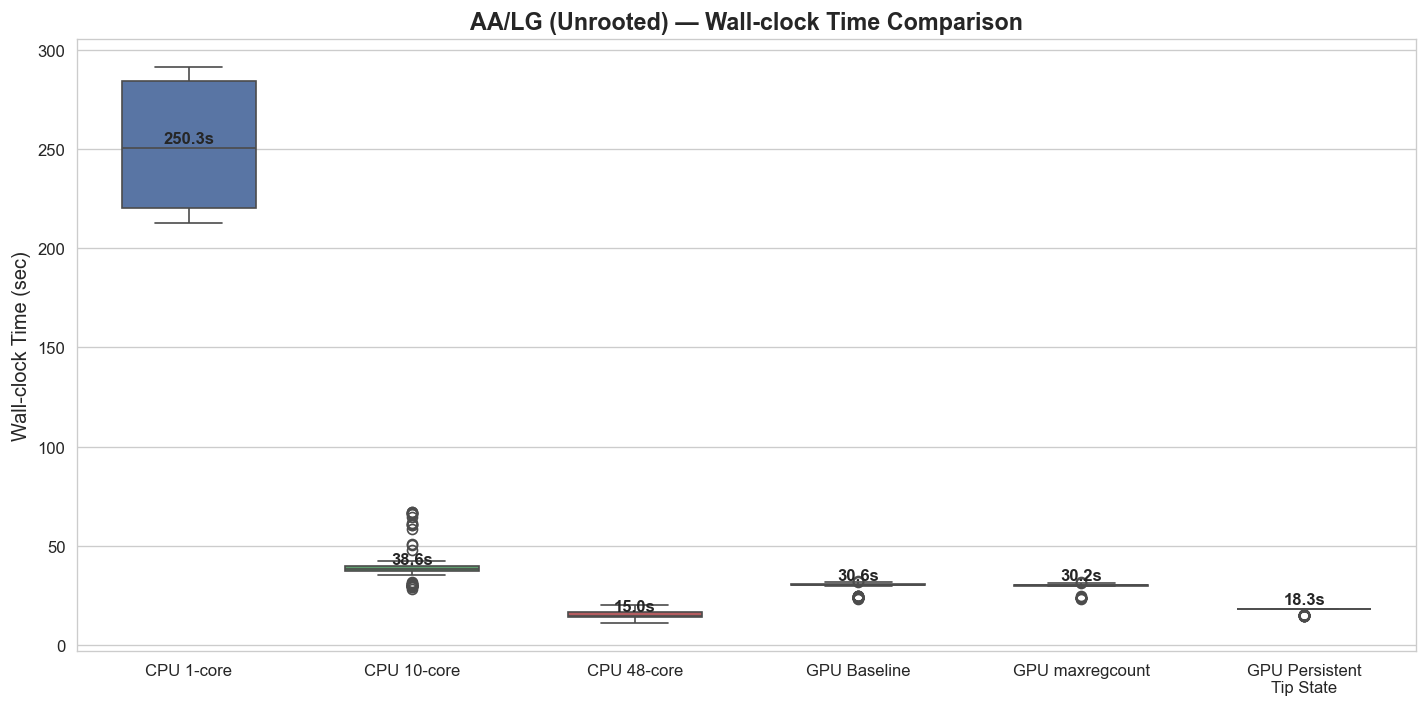

Saved: walltime_all_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/4088550364.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/4088550364.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=10)


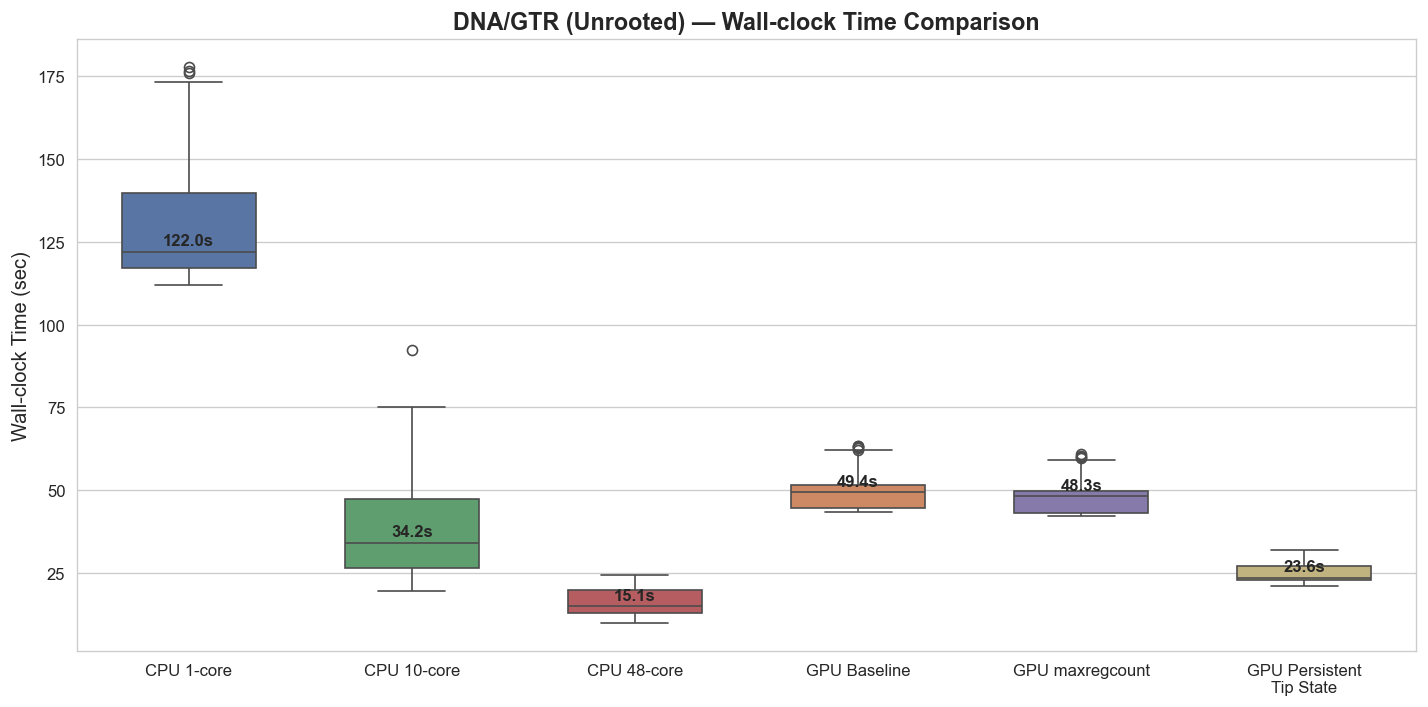

Saved: walltime_all_DNA_GTR.png


In [8]:
backend_order = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC', 'GPU_MAXREG', 'GPU_TIP_STATE']
backend_colors = {
    'VANILA': '#4C72B0',
    'OMP_10': '#55A868',
    'OMP_48': '#C44E52',
    'OPENACC': '#DD8452',
    'GPU_MAXREG': '#8172B2',
    'GPU_TIP_STATE': '#CCB974'
}
backend_labels = {
    'VANILA': 'CPU 1-core',
    'OMP_10': 'CPU 10-core',
    'OMP_48': 'CPU 48-core',
    'OPENACC': 'GPU Baseline',
    'GPU_MAXREG': 'GPU maxregcount',
    'GPU_TIP_STATE': 'GPU Persistent\nTip State'
}

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model)]
    present = [b for b in backend_order if b in subset['backend'].unique()]
    palette = [backend_colors[b] for b in present]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=subset, x='backend', y='walltime',
               order=present, palette=palette, ax=ax, width=0.6)
    
    ax.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=10)
    ax.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{data_type}/{model} (Unrooted) — Wall-clock Time Comparison',
                fontsize=14, fontweight='bold')
    
    medians = subset.groupby('backend')['walltime'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax.text(i, medians[b] + 1, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    fname = f'walltime_all_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 5. Speedup Analysis

In [9]:
median_wt = df.groupby(['data_type', 'model', 'tree', 'backend'])['walltime'].median().reset_index()
pivot = median_wt.pivot_table(index=['data_type', 'model', 'tree'],
                               columns='backend', values='walltime').reset_index()

# Speedups relative to VANILA
for backend in ['OMP_10', 'OMP_48', 'OPENACC', 'GPU_MAXREG', 'GPU_TIP_STATE']:
    if backend in pivot.columns and 'VANILA' in pivot.columns:
        pivot[f'speedup_vs_1core_{backend}'] = pivot['VANILA'] / pivot[backend]

# Speedups of TIP_STATE relative to other GPU backends
if 'GPU_TIP_STATE' in pivot.columns:
    if 'OPENACC' in pivot.columns:
        pivot['speedup_tip_vs_baseline'] = pivot['OPENACC'] / pivot['GPU_TIP_STATE']
    if 'GPU_MAXREG' in pivot.columns:
        pivot['speedup_tip_vs_maxreg'] = pivot['GPU_MAXREG'] / pivot['GPU_TIP_STATE']

pivot.to_csv(SAVE_DIR / 'speedup_pivot.csv', index=False)

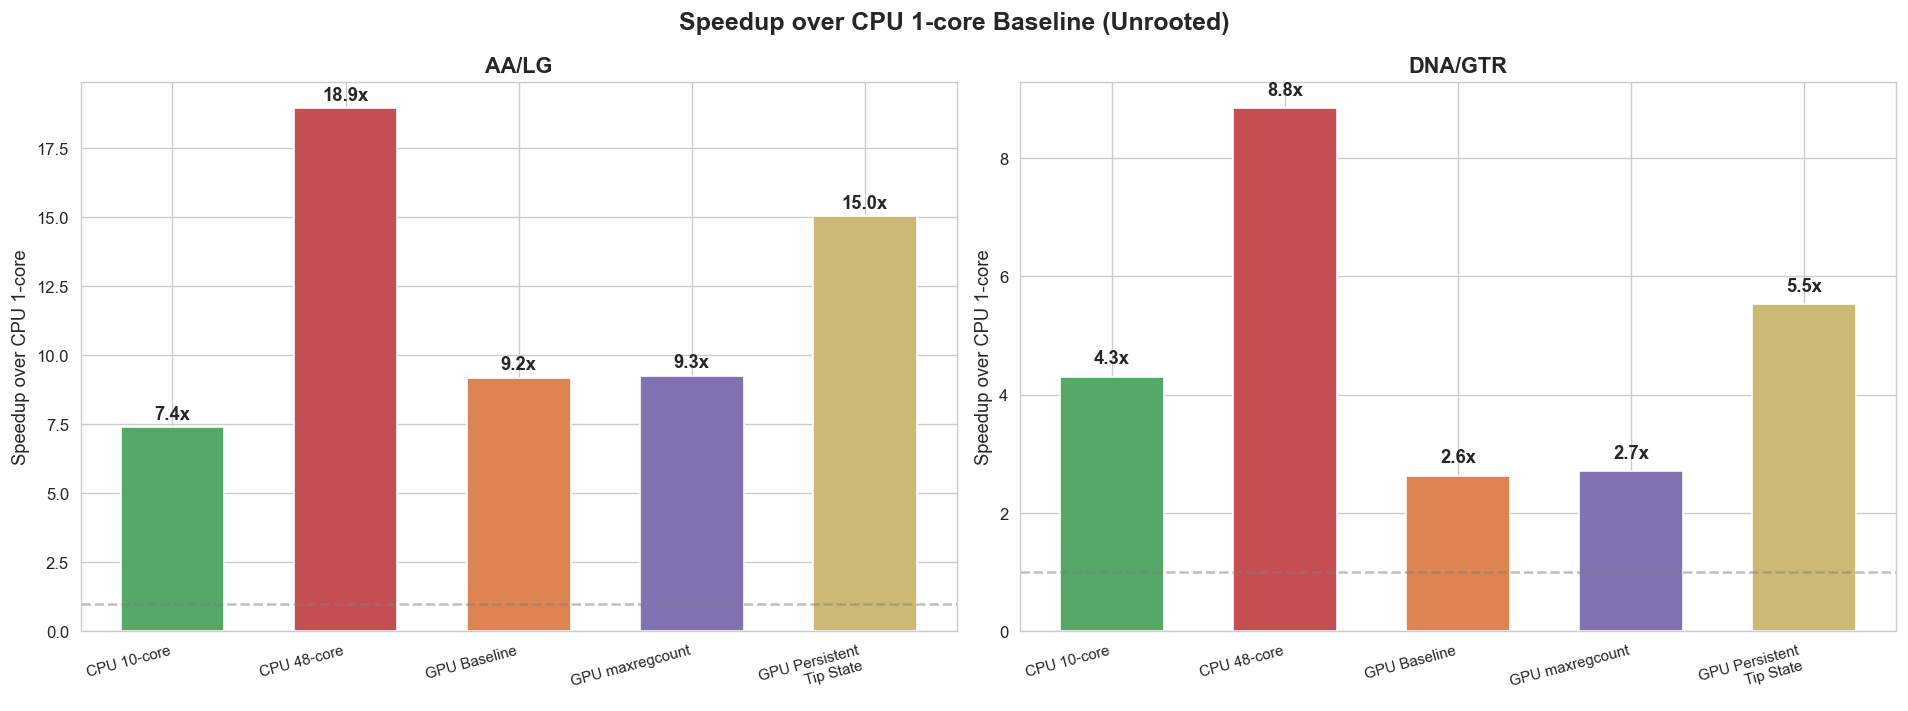

Saved: speedup_vs_1core.png


In [10]:
# Speedup bar chart: all backends vs 1-core
speedup_backends = ['OMP_10', 'OMP_48', 'OPENACC', 'GPU_MAXREG', 'GPU_TIP_STATE']
bar_colors = ['#55A868', '#C44E52', '#DD8452', '#8172B2', '#CCB974']
bar_labels = ['CPU 10-core', 'CPU 48-core', 'GPU Baseline', 'GPU maxregcount', 'GPU Persistent\nTip State']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (data_type, model) in zip(axes, [('AA', 'LG'), ('DNA', 'GTR')]):
    sub = pivot[(pivot['data_type'] == data_type) & (pivot['model'] == model)]
    
    present_cols = []
    present_colors = []
    present_labels = []
    for b, c, l in zip(speedup_backends, bar_colors, bar_labels):
        col = f'speedup_vs_1core_{b}'
        if col in sub.columns and sub[col].notna().any():
            present_cols.append(col)
            present_colors.append(c)
            present_labels.append(l)
    
    means = [sub[c].mean() for c in present_cols]
    
    bars = ax.bar(range(len(present_cols)), means, color=present_colors, width=0.6)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
               f'{val:.1f}x', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xticks(range(len(present_cols)))
    ax.set_xticklabels(present_labels, fontsize=9, rotation=15, ha='right')
    ax.set_ylabel('Speedup over CPU 1-core', fontsize=11)
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{data_type}/{model}', fontsize=13, fontweight='bold')

fig.suptitle('Speedup over CPU 1-core Baseline (Unrooted)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'speedup_vs_1core.png', bbox_inches='tight')
plt.show()
print('Saved: speedup_vs_1core.png')

In [11]:
# GPU-only speedup: tip state vs baseline GPU and maxregcount
gpu_speedup_cols = [c for c in pivot.columns if c.startswith('speedup_tip_vs_')]
if gpu_speedup_cols:
    gpu_speedup_summary = pivot.groupby(['data_type', 'model'])[gpu_speedup_cols].agg(['mean', 'median', 'min', 'max']).round(2)
    print('GPU Persistent Tip State speedup over other GPU builds:')
    display(gpu_speedup_summary)
    gpu_speedup_summary.to_csv(SAVE_DIR / 'gpu_speedup_summary.csv')

GPU Persistent Tip State speedup over other GPU builds:


backend         speedup_tip_vs_baseline                     \
                                   mean median   min   max   
data_type model                                              
AA        LG                       1.66   1.67  1.60  1.69   
DNA       GTR                      2.11   2.11  2.06  2.15   

backend         speedup_tip_vs_maxreg                     
                                 mean median   min   max  
data_type model                                           
AA        LG                     1.65   1.66  1.59  1.67  
DNA       GTR                    2.05   2.06  2.00  2.09

## 6. GPU Evolution: Baseline → maxregcount → Persistent Tip State

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/2951126388.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/2951126388.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(p_labels, fontsize=11)


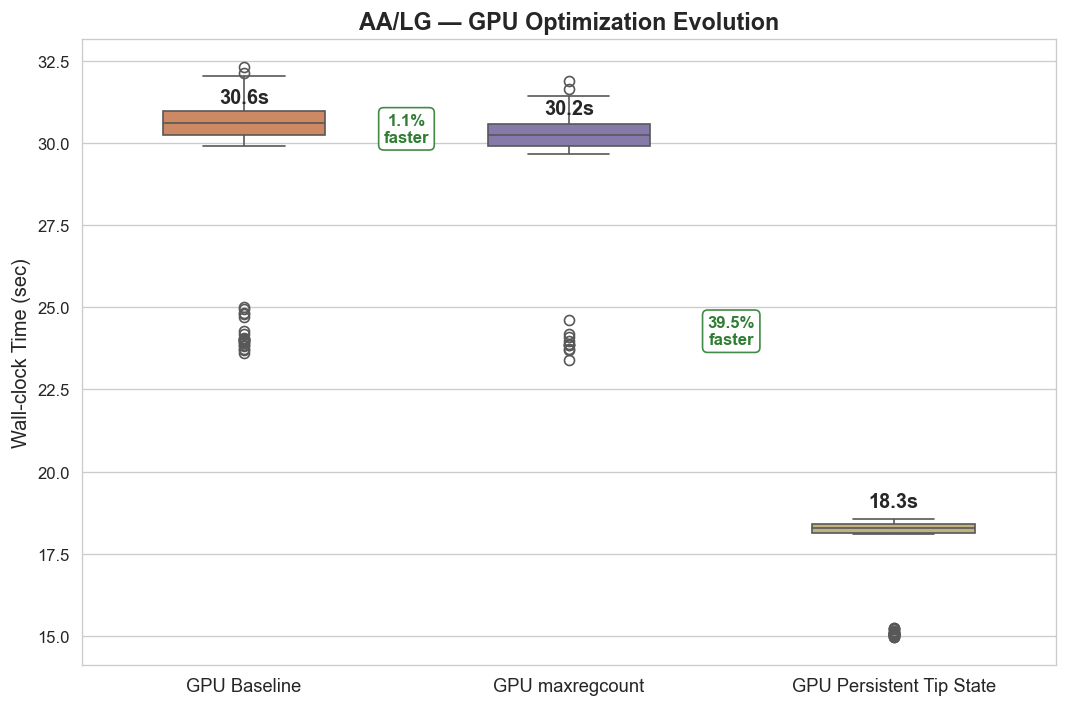

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/2951126388.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',


Saved: gpu_evolution_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/2951126388.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(p_labels, fontsize=11)


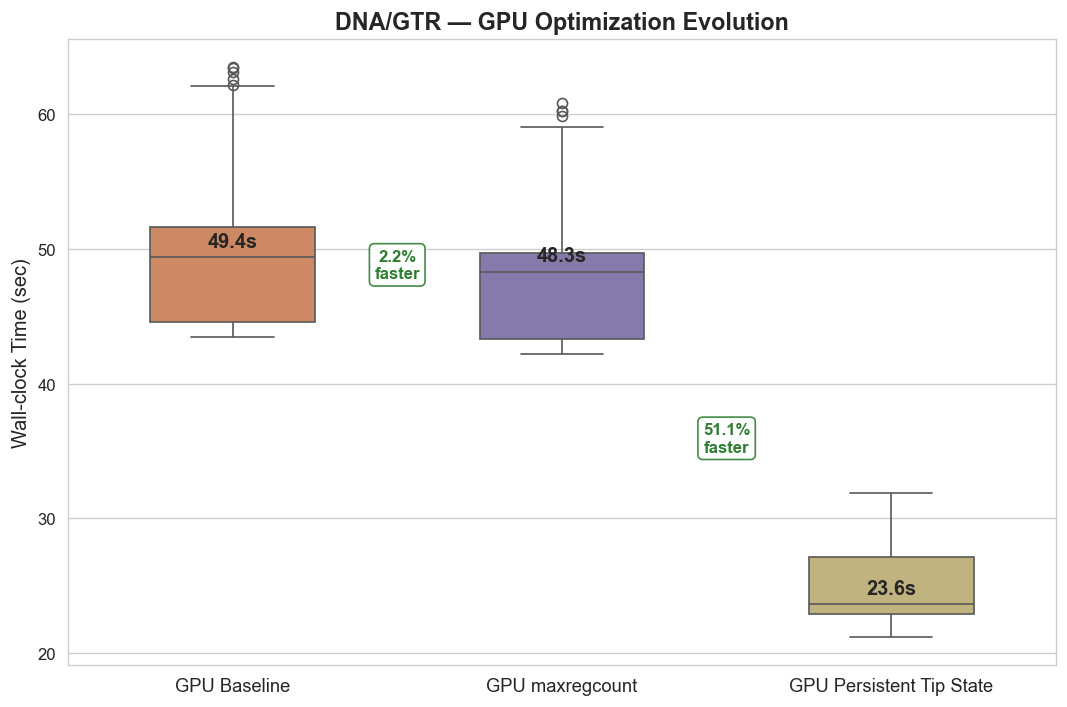

Saved: gpu_evolution_DNA_GTR.png


In [12]:
gpu_backends_order = ['OPENACC', 'GPU_MAXREG', 'GPU_TIP_STATE']
gpu_labels = ['GPU Baseline', 'GPU maxregcount', 'GPU Persistent Tip State']
gpu_colors = ['#DD8452', '#8172B2', '#CCB974']

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(gpu_backends_order)]
    present = [b for b in gpu_backends_order if b in subset['backend'].unique()]
    p_colors = [gpu_colors[gpu_backends_order.index(b)] for b in present]
    p_labels = [gpu_labels[gpu_backends_order.index(b)] for b in present]
    
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.boxplot(data=subset, x='backend', y='walltime',
               order=present, palette=p_colors, ax=ax, width=0.5)
    
    ax.set_xticklabels(p_labels, fontsize=11)
    ax.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{data_type}/{model} — GPU Optimization Evolution',
                fontsize=14, fontweight='bold')
    
    medians = subset.groupby('backend')['walltime'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax.text(i, medians[b] + 0.5, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # Add improvement arrows between bars
    for i in range(len(present) - 1):
        if present[i] in medians.index and present[i+1] in medians.index:
            m1, m2 = medians[present[i]], medians[present[i+1]]
            pct = (m1 - m2) / m1 * 100
            mid_y = (m1 + m2) / 2
            ax.annotate(f'{pct:.1f}%\nfaster',
                       xy=(i + 0.5, mid_y), fontsize=10, fontweight='bold',
                       ha='center', va='center', color='#2E7D32',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2E7D32', alpha=0.9))
    
    plt.tight_layout()
    fname = f'gpu_evolution_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 7. Per-Tree: GPU Tip State vs All Other Backends

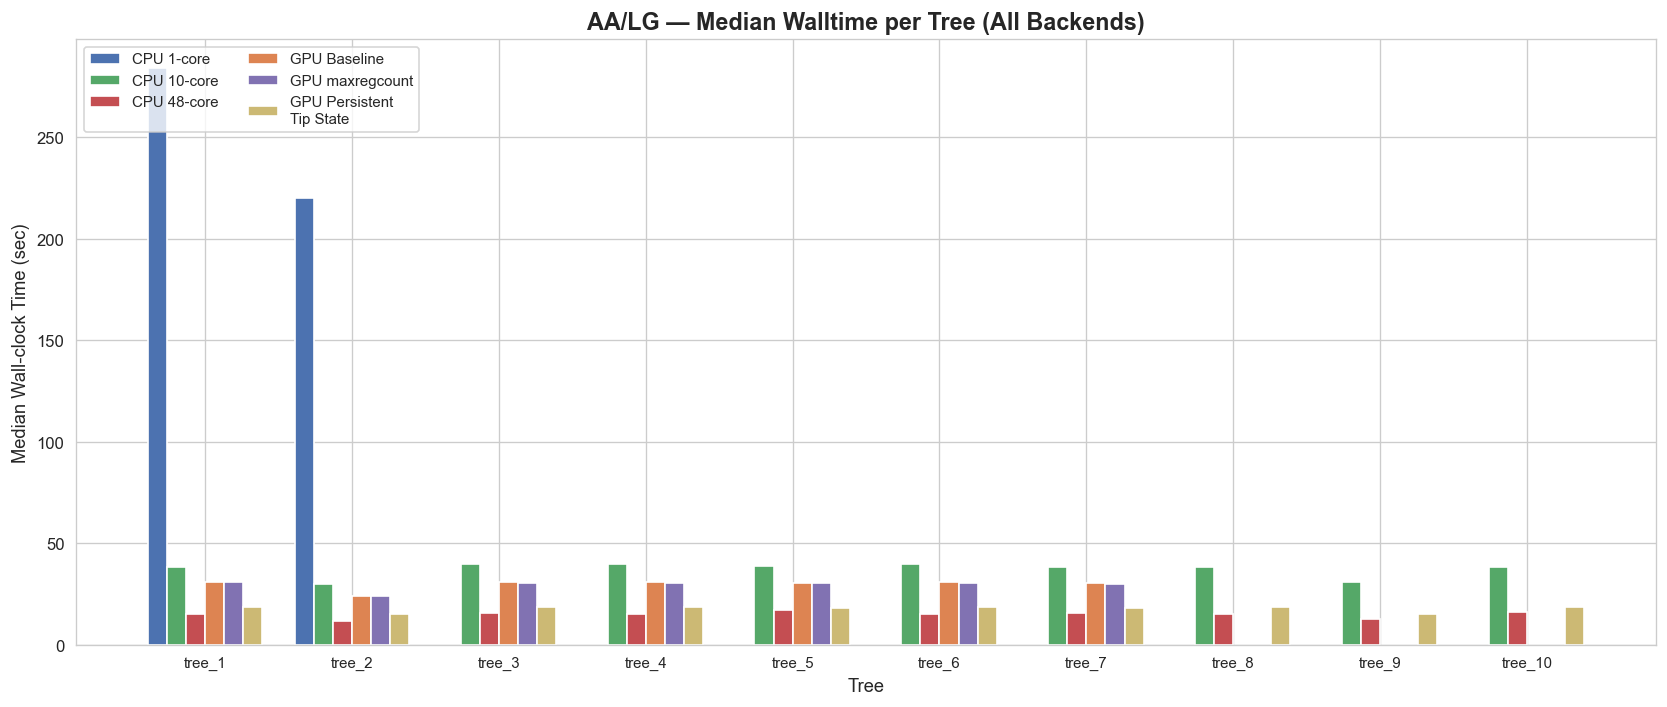

Saved: per_tree_all_AA_LG.png


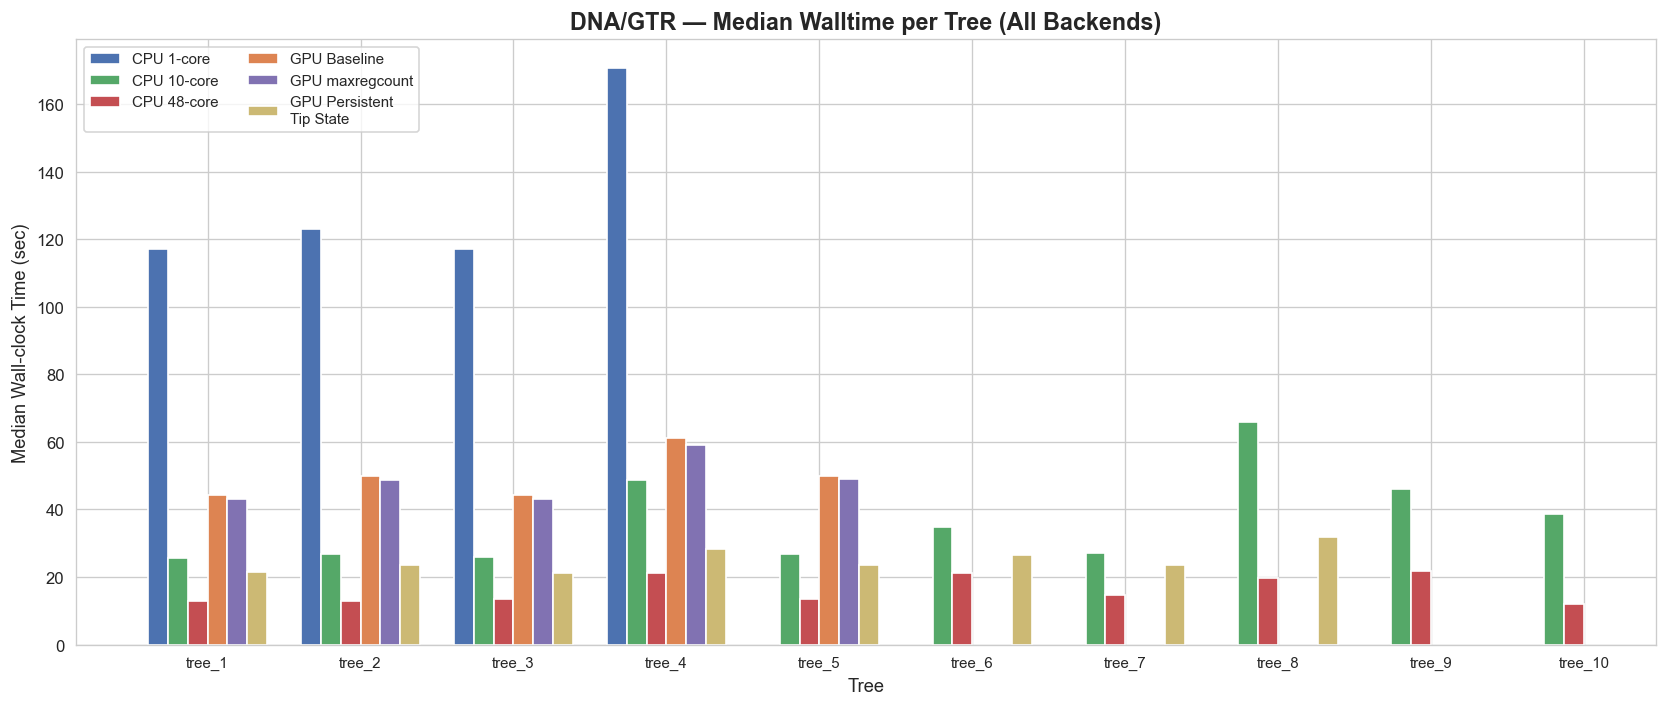

Saved: per_tree_all_DNA_GTR.png


In [13]:
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model)]
    present = [b for b in backend_order if b in subset['backend'].unique()]
    trees = sorted(subset['tree'].unique(), key=lambda x: int(x.split('_')[1]))
    
    # Median walltime per tree per backend
    tree_medians = subset.groupby(['tree', 'backend'])['walltime'].median().reset_index()
    tree_pivot = tree_medians.pivot_table(index='tree', columns='backend', values='walltime')
    tree_pivot = tree_pivot.reindex(trees)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(trees))
    width = 0.13
    
    for i, b in enumerate(present):
        if b in tree_pivot.columns:
            vals = tree_pivot[b].values
            ax.bar(x + i * width, vals, width,
                  label=backend_labels.get(b, b), color=backend_colors[b])
    
    ax.set_xticks(x + width * (len(present) - 1) / 2)
    ax.set_xticklabels(trees, fontsize=9)
    ax.set_ylabel('Median Wall-clock Time (sec)', fontsize=11)
    ax.set_xlabel('Tree', fontsize=11)
    ax.legend(fontsize=9, ncol=2)
    ax.set_title(f'{data_type}/{model} — Median Walltime per Tree (All Backends)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f'per_tree_all_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 8. Improvement: GPU Tip State vs GPU Baseline (per tree)

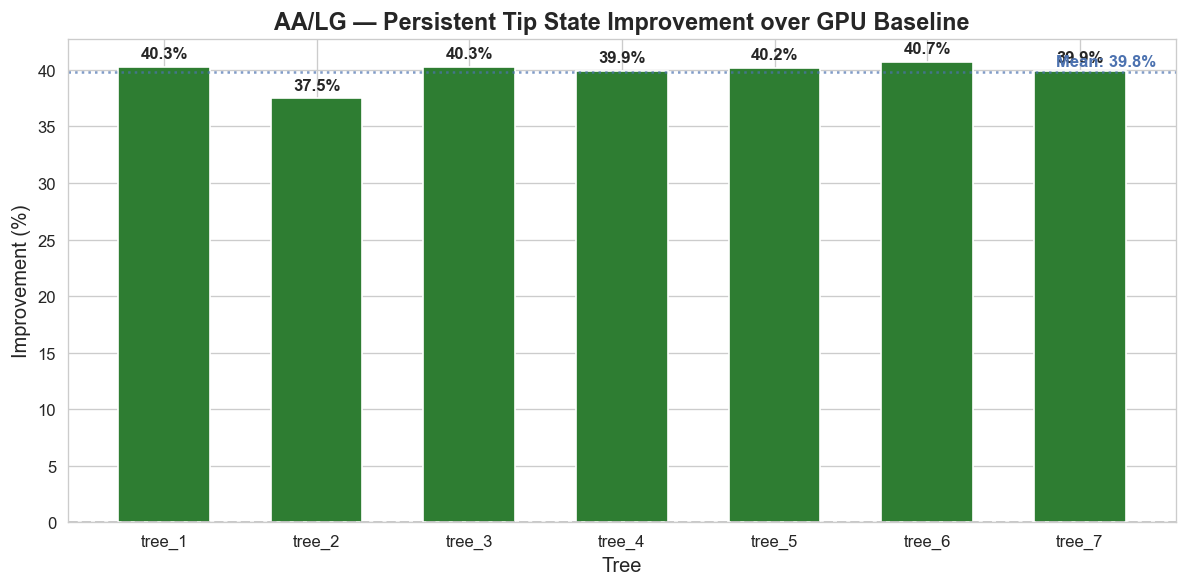

Saved: improvement_vs_baseline_AA_LG.png


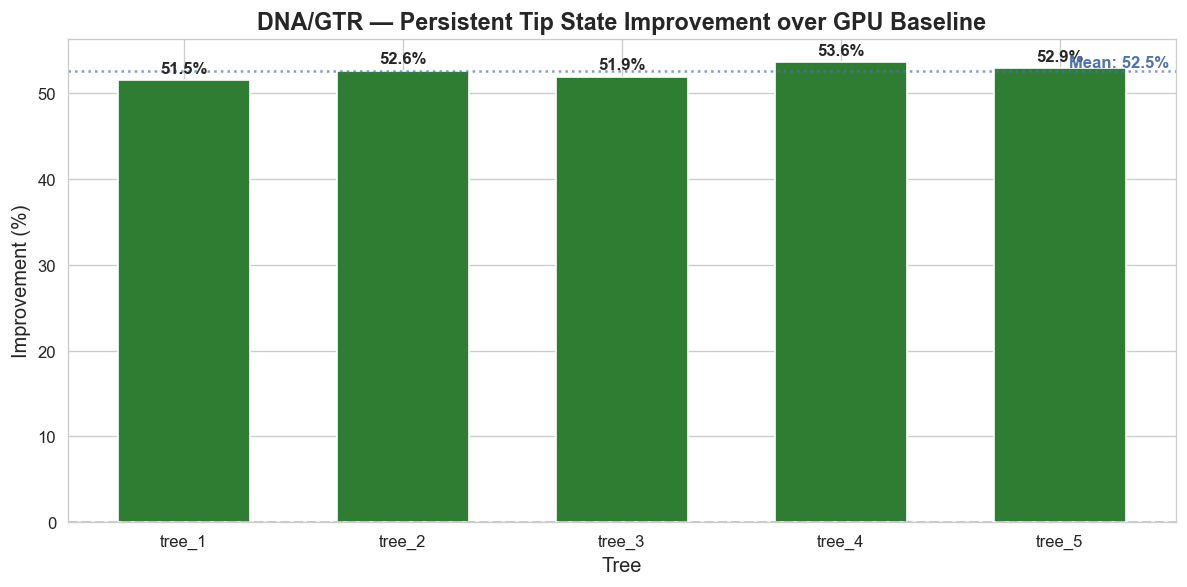

Saved: improvement_vs_baseline_DNA_GTR.png


In [14]:
if 'speedup_tip_vs_baseline' in pivot.columns:
    for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
        sub = pivot[(pivot['data_type'] == data_type) & (pivot['model'] == model)].dropna(
            subset=['speedup_tip_vs_baseline']).copy()
        if sub.empty:
            continue
        
        sub['improvement_pct'] = ((sub['OPENACC'] - sub['GPU_TIP_STATE']) / sub['OPENACC'] * 100).round(1)
        trees = sorted(sub['tree'].values, key=lambda x: int(x.split('_')[1]))
        sub_sorted = sub.set_index('tree').loc[trees]
        
        fig, ax = plt.subplots(figsize=(10, 5))
        colors = ['#2E7D32' if v > 0 else '#C44E52' for v in sub_sorted['improvement_pct']]
        bars = ax.bar(range(len(trees)), sub_sorted['improvement_pct'].values,
                     color=colors, width=0.6)
        
        for bar, val in zip(bars, sub_sorted['improvement_pct'].values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                   bar.get_height() + (0.5 if val >= 0 else -2),
                   f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        mean_imp = sub_sorted['improvement_pct'].mean()
        ax.axhline(y=mean_imp, color='#4C72B0', linestyle=':', alpha=0.7)
        ax.text(len(trees) - 0.5, mean_imp + 0.5, f'Mean: {mean_imp:.1f}%',
               fontsize=10, color='#4C72B0', fontweight='bold', ha='right')
        
        ax.set_xticks(range(len(trees)))
        ax.set_xticklabels(trees, fontsize=10)
        ax.set_ylabel('Improvement (%)', fontsize=12)
        ax.set_xlabel('Tree', fontsize=12)
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_title(f'{data_type}/{model} — Persistent Tip State Improvement over GPU Baseline',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        fname = f'improvement_vs_baseline_{data_type}_{model}.png'
        plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

## 9. Optimization Time Comparison (All GPU builds)

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/3567895956.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/3567895956.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(p_labels, fontsize=10)


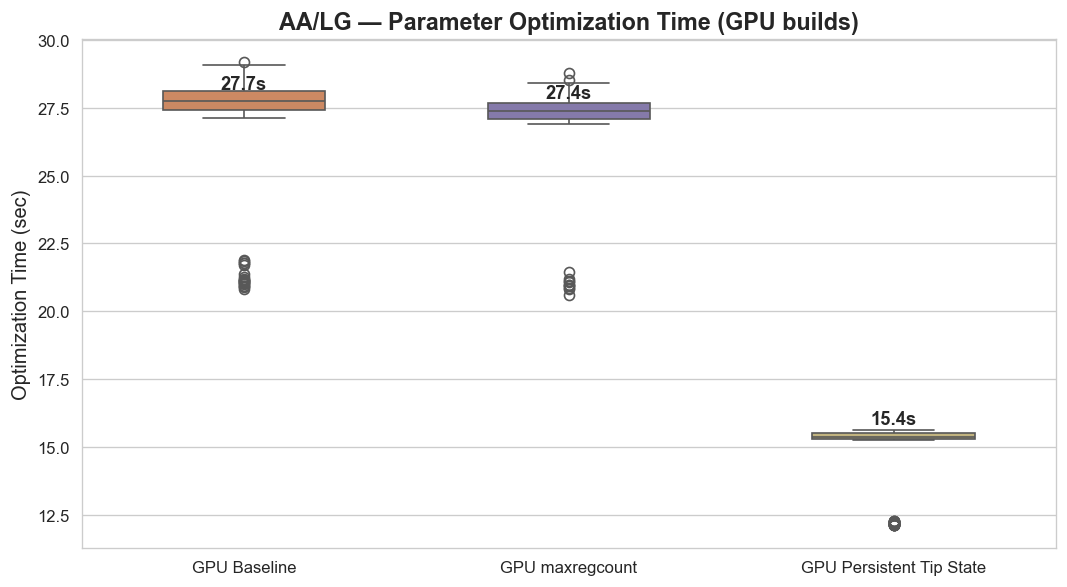

Saved: opt_time_gpu_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/3567895956.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_67474/3567895956.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(p_labels, fontsize=10)


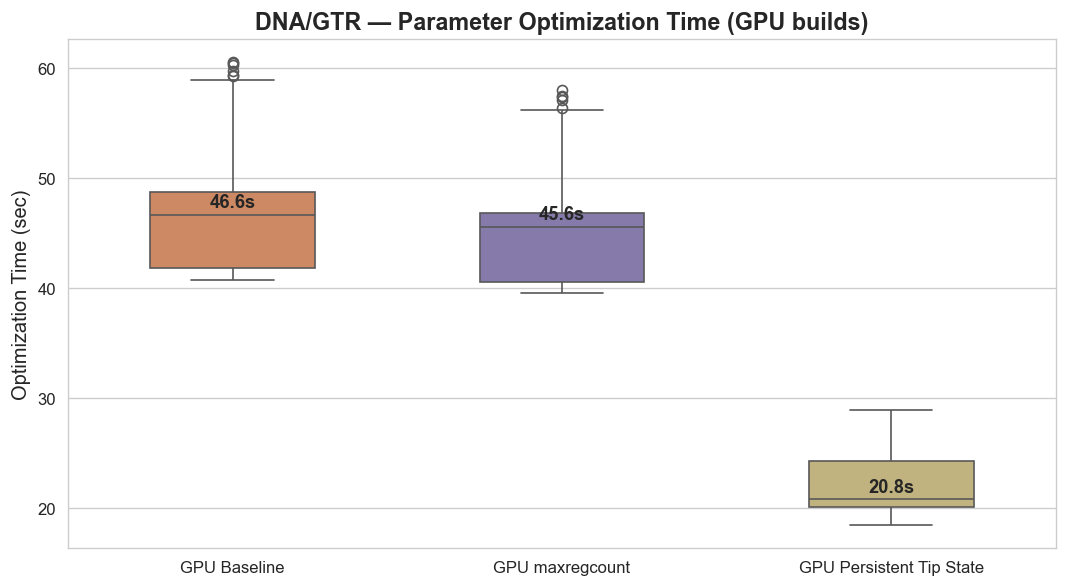

Saved: opt_time_gpu_DNA_GTR.png


In [15]:
gpu_all = df[df['backend'].isin(['OPENACC', 'GPU_MAXREG', 'GPU_TIP_STATE'])].dropna(subset=['opt_time'])

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = gpu_all[(gpu_all['data_type'] == data_type) & (gpu_all['model'] == model)]
    present = [b for b in gpu_backends_order if b in subset['backend'].unique()]
    p_colors = [gpu_colors[gpu_backends_order.index(b)] for b in present]
    p_labels = [gpu_labels[gpu_backends_order.index(b)] for b in present]
    
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(data=subset, x='backend', y='opt_time',
               order=present, palette=p_colors, ax=ax, width=0.5)
    
    ax.set_xticklabels(p_labels, fontsize=10)
    ax.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{data_type}/{model} — Parameter Optimization Time (GPU builds)',
                fontsize=14, fontweight='bold')
    
    medians = subset.groupby('backend')['opt_time'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax.text(i, medians[b] + 0.3, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    fname = f'opt_time_gpu_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 10. Final Summary Table

In [16]:
final = df.groupby(['data_type', 'model', 'backend']).agg(
    mean_walltime=('walltime', 'mean'),
    median_walltime=('walltime', 'median'),
    std_walltime=('walltime', 'std'),
    mean_opt_time=('opt_time', 'mean'),
    mean_logl=('log_likelihood', 'mean'),
    n_runs=('walltime', 'count')
).round(2).reset_index()

# Speedup vs 1-core
vanila = final[final['backend'] == 'VANILA'][['data_type', 'model', 'median_walltime']].rename(
    columns={'median_walltime': 'vanila_median'})
final = final.merge(vanila, on=['data_type', 'model'], how='left')
final['speedup_vs_1core'] = (final['vanila_median'] / final['median_walltime']).round(2)

# Speedup vs baseline GPU
gpu_base = final[final['backend'] == 'OPENACC'][['data_type', 'model', 'median_walltime']].rename(
    columns={'median_walltime': 'gpu_base_median'})
final = final.merge(gpu_base, on=['data_type', 'model'], how='left')
final['speedup_vs_gpu_base'] = (final['gpu_base_median'] / final['median_walltime']).round(2)

final = final.drop(columns=['vanila_median', 'gpu_base_median'])
final.to_csv(SAVE_DIR / 'final_summary.csv', index=False)

display(final.style.format({
    'speedup_vs_1core': '{:.2f}x',
    'speedup_vs_gpu_base': '{:.2f}x',
    'mean_logl': '{:.3f}'
}).background_gradient(subset=['speedup_vs_1core'], cmap='Greens')
 .background_gradient(subset=['speedup_vs_gpu_base'], cmap='Purples'))

,data_type,model,backend,mean_walltime,median_walltime,std_walltime,mean_opt_time,mean_logl,n_runs,speedup_vs_1core,speedup_vs_gpu_base
0,AA,LG,GPU_MAXREG,29.490000,30.250000,2.330000,26.590000,-87470599.180,70,8.27x,1.01x
1,AA,LG,GPU_TIP_STATE,17.670000,18.290000,1.310000,14.800000,-86324112.640,99,13.68x,1.67x
2,AA,LG,OMP_10,40.600000,38.560000,9.580000,39.260000,-86328013.800,100,6.49x,0.79x
3,AA,LG,OMP_48,15.460000,15.020000,2.400000,14.030000,-86328013.800,100,16.66x,2.04x
4,AA,LG,OPENACC,29.860000,30.600000,2.430000,26.950000,-87477966.390,137,8.18x,1.00x
5,AA,LG,VANILA,251.790000,250.290000,33.780000,248.780000,-89703067.780,20,1.00x,0.12x
6,DNA,GTR,GPU_MAXREG,48.680000,48.260000,5.990000,45.920000,-66837691.060,50,2.53x,1.02x
7,DNA,GTR,GPU_TIP_STATE,25.050000,23.620000,3.410000,22.240000,-66557528.130,80,5.17x,2.09x
8,DNA,GTR,OMP_10,38.110000,34.240000,14.920000,36.910000,-67437010.890,100,3.56x,1.44x
9,DNA,GTR,OMP_48,16.180000,15.050000,4.100000,15.060000,-67437010.890,100,8.11x,3.28x
